**Author:** Nishan Karki

<hr>

## Table of Contents

**1. Setup & Configuration**
   - 1.1 Import Libraries
   - 1.2 Verify Tables


**2. Business Context**
   - 2.1 Business Problem
   - 2.2 Analytical Objective
   - 2.3 Hypothesis
   - 2.4 Data Mapping

**3. Analysis**
   - 3.1 Baseline Revenue Metrics
   - 3.2 Order Status Breakdown
   - 3.3 Category-Level Revenue Leakage
   - 3.4 Category Level Comparison (Volume vs Revenue)

**4. Key Findings & Recommendations**



# 1. Setup & Configuration:

## 1.1 Import Libraries:

In [1]:
import pandas as pd
import os
import numpy as np
from IPython.display import display, Markdown, Image, HTML
import sys
import sqlite3
from pathlib import Path
import chart_studio.plotly as py
import plotly.express as px
import plotly.graph_objects as go
import cufflinks as cf
import matplotlib.pyplot as plt
%matplotlib inline
import importlib
import warnings
warnings.filterwarnings("ignore")

from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)
cf.go_offline()

# Add the project root to the system path:
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

# Import custome modules:
from src.revenue_leakage import revenue_leakage_metrics, revenue_leakage_summary
from plots import revenue_leakage_plots
from utils import helper

In [3]:
# A helper function to reload the package to pick up necessary changes:
def reload_package():
    importlib.reload(revenue_leakage_metrics)
    importlib.reload(revenue_leakage_summary)
    importlib.reload(helper)
    print("Packages reloaded!!")

In [4]:
# Create a global path for all SQL files that is related to the revenue leakage analysis:
SQL_BASE_PATH = Path("../sql/02_Revenue_Leakage_Analysis")

## 1.2 Verify Tables:

In [5]:
tables = helper.extract_table_names(conn=conn)

In [6]:
tables

,name
0,customers
1,geolocation
2,orders
3,order_items
4,order_payments
5,order_reviews
6,products
7,sellers
8,product_category_translation


# 2. Business Context:

## 2.1 Business Problem:
<hr>

In e-commerce, revenue loss is not caused solely by low demand or poor sales performance. A significant portion of lost revenue originates from orders that were successfully placed but never fulfilled due to cancellations.

Each cancelled order represents:
1. Lost revenue that was expected but never realized
2. Wasted logistics and operational effort (inventory handling, processing)
3. Poor customer experience, which can reduce trust
4. Potential long-term customer churn


Importantly, not all cancellations have the same business impact.
Cancellations in low-volume but high-value categories can be significantly more damaging than a large number of cancellations in low-priced categories.

Therefore, treating all cancellations equally may lead to misaligned priorities.
A data-driven approach is required to identify where revenue leakage is most severe and where intervention should be prioritized.

<hr>

## 2.2 Analytical Objective:
<hr>

The objective of this analysis is to identify product categories that contribute most to revenue leakage by evaluating:
   1. Cancellation rates (operational reliability)
   2. Absolute revenue lost due to cancellations (financial impact)
   3. Relative revenue impact compared to other categories for prioritization
    

This allows the business to distinguish between:
1. Operational inefficiencies (frequent but low-impact cancellations, cost-wise)
2. High-risk revenue segments (infrequent but expensive cancellations)
3. Low-priority noise that doesn't require immediate action


<hr> 

## 2.3 Hypothesis:
<hr>

Before conducting the analysis, the following hypothesis are formulated:

**Hypothesis 1:**
High-priced or logistics-heavy categories will show disproportionately high revenue loss, even if cancellation volume is low.

**Hypothesis 2:**
Some categories may have high cancellation rates but low revenue impact, indicating operational inefficiencies rather than financial risk.


<hr>

## 2.4 Data Mapping:
<hr>

The tables we will be using for this business problem:

`1. orders:` to identify the canceled orders via `order_status`

`2. order_items:` to calculate the revenues or possible revenues based on the order status

`3. products:` to map the items to the categories

`4. product_category_translation:` for readable category names


# 3. Analysis:

## 3.1 Baseline Revenue Metrics:

###  Check the duplicates:

In [7]:
duplicates = helper.check_duplicates(conn=conn)
duplicates

,order_id,order_item_id,total


There is no any duplicates. A duplicate data would have falsify the revenue calculations, since there are no any duplicates, summing at the row level is safe.

### Baseline Revenue Metrics & Revenue Leakage Analysis:

For this metrics, I will be considering both `price` + `freight_value` 

Here, `order_id` and `order_item_id` will be crucial, where, `order_id` represents an ID for one checkout
where as `order_item_id` represents the number of items in that particular checkout.

In [30]:
reload_package()

Packages reloaded!!


In [31]:
# 1. Execute the SQL code to extract the revenue metrics:

revenue_baseline_metrics = (revenue_leakage_metrics.get_baseline_metrics(conn=conn,sql_base_path=SQL_BASE_PATH))

In [32]:
# 2. A function that calculates the revenue leakage in percentage:

revenue_leakage_percentage = revenue_leakage_metrics.generate_revenue_leakage(revenue_baseline_metrics=revenue_baseline_metrics)

In [56]:
revenue_leakage_summary.revenue_metrics_summary(revenue_baseline_metrics, revenue_leakage_percentage)


    
## Baseline Revenue Metrics: Summary
----------------------------------------------------------------------------------------------------

- The headline revenue metrics provide a high-level view of the platform’s overall revenue performance 
and operational efficiency.

- Out of a total market opportunity of **R\$15.84M**, the business successfully 
realized **R\$15.42M** in revenue from `delivered orders`, indicating that the vast 
majority of potential revenue was converted into actual sales.

- Revenue lost due to order cancellations amounts to **R\$0.11M**, resulting in an 
overall revenue leakage of just **0.69%**. <br>

The metrics and the amounts have been presented in a tabular format below:




Metrics,Amount_millions
Total Market Opportunity,15.84
Total Revenue Loss From Cancellation,0.11
Total Revenue Realized (Delivered Items),15.42


<br> From a business perspective, this is a strong operational signal:

1. A revenue leakage below 1% (**0.69%**) suggests effective order fulfillment and low cancellation impact

2. The gap between expected and realized revenue is minimal, indicating stable customer transactions and reliable logistics

3. Revenue loss from cancellations exists but is not a material risk at the aggregate level.


However, while the overall leakage percentage is low, this aggregate view can mask underlying patterns. 
A small total leakage may still be concentrated within specific order types, customer segments, or specific 
product categories, which could represent optimization opportunities.

This motivates a deeper, granular analysis, starting with a breakdown of orders by status.

#### NEXT SECTION: `Order Status Breakdown`


## 3.2 Order Status Breakdown:

### 3.2.1 Breakdown of the total number of orders based on the `order_status`:

In [35]:
reload_package()

Packages reloaded!!


In [36]:
breakdown_of_orders = revenue_leakage_metrics.get_breakdown_of_orders(conn=conn, sql_base_path=SQL_BASE_PATH)
breakdown_of_orders

,order_status,total_n_orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [37]:
total_n_orders = breakdown_of_orders[['total_n_orders']].sum()[0]
print(total_n_orders)

99441


In [38]:
reload_package()

Packages reloaded!!


### 3.2.2 Breakdown on Cancelled Orders:

Cancelled Orders without items:

In [39]:
cancelled_orders_without_items = revenue_leakage_metrics.get_break_down_on_cncl_orders(conn=conn,
                                                                              sql_base_path=SQL_BASE_PATH)['without_items']

cancelled_orders_without_items

,canceled_orders_without_items
0,164


Cancelled Orders with items:

In [40]:
cancelled_orders_with_items = revenue_leakage_metrics.get_break_down_on_cncl_orders(conn=conn,
                                                                              sql_base_path=SQL_BASE_PATH)['with_items']

cancelled_orders_with_items

,canceled_orders_with_items
0,461


Concatenating the two results:

In [41]:
cancelled_orders_granularity = pd.concat([cancelled_orders_with_items, cancelled_orders_without_items], axis=1).T
cancelled_orders_granularity = (cancelled_orders_granularity.reset_index()
                                .rename(columns = {'index': 'Cancelled Orders',
                                                  0: 'Total Count'}))
cancelled_orders_granularity  

,Cancelled Orders,Total Count
0,canceled_orders_with_items,461
1,canceled_orders_without_items,164


In [55]:
revenue_leakage_summary.order_status_breakdown_summary(breakdown_of_orders,
                                                      total_n_orders,
                                                      cancelled_orders_with_items,
                                                      cancelled_orders_without_items)

 
## Order Status Breakdown: Summary

----------------------------------------------------------------------------------------------------
    
The company had a total number of **99441** orders. The table below summarizes the break down of these 
orders.



order_status,total_n_orders
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



The company had a total of **625** canceled orders. If we further breakdown these canceled orders,
there are two kinds of orders:
1. Canceled orders `with-items`: **461**
2. Canceled orders `without-items`: **164**

Which results to total canceled orders we have i.e. 

**Total canceled orders** (625) = 
**Total canceled orders with items** (461) + **Total canceled orders without items** (164)


## 3.3 Category-Level Revenue Leakage:

The goal is to look at different categories where the orders were canceled and find their contribution in the
total revenue leakage:

#### Get the details about canceled orders:

In [50]:
# Get the total number of canceled orders:
cancelled_orders = breakdown_of_orders[breakdown_of_orders['order_status'] == 'canceled']['total_n_orders'].iloc[0]

# Get the canceled orders with items:
cancelled_orders_with_items_val = cancelled_orders_with_items.iloc[:, 0].values[0]

# Get the canceled orders without items:
cancelled_orders_without_items_val = cancelled_orders_without_items.iloc[:, 0].values[0]

# Get the revenue leakage percentage:
revenue_leakage_percentage = revenue_leakage_metrics.generate_revenue_leakage(revenue_baseline_metrics)

In [49]:
reload_package()

Packages reloaded!!


#### Get the details about canceled orders at the `product level`:

In [51]:
# Cancled orders with their product category and their amount and contribution to the revenue leakage:
revenue_lost_per_prodct_cat = revenue_leakage_metrics.get_cncl_by_prod_cat_amount(conn=conn, sql_base_path=SQL_BASE_PATH)


# Top 10 product categories based on the revenue leakge out of all:
top_10_canceled_prod_category = revenue_lost_per_prodct_cat.head(10)


# Product category with the maximum amount lost due to order cancellation:
prod_cat_w_max_amount = (revenue_lost_per_prodct_cat[revenue_lost_per_prodct_cat['total_amount'] 
                                        == 
                                        revenue_lost_per_prodct_cat['total_amount'].max()])

# Product category with the minimum amount lost due to order cancellation:
prod_cat_w_min_amount = (revenue_lost_per_prodct_cat[revenue_lost_per_prodct_cat['total_amount'] 
                                        == 
                                        revenue_lost_per_prodct_cat['total_amount'].min()])

#### Genereate the plot to display the `top_10_canceled_prod_category`:

In [52]:
fig = (revenue_leakage_plots.plot_top_10_product_categories_by_revenue_loss
       (top_10_canceled_prod_category=top_10_canceled_prod_category))

#### Generate the summary for the `Category-Level Revenue Leakage` section:

 
## Category-Level Revenue Leakage: Summary:
                     
----------------------------------------------------------------------------------------------------
    
We found out that there is a total of: **625 cancelled orders** and a
revenue leakage of: **0.69 %**, if we drill down, there are two categories of order cancellations:

1. **Total canceled orders with items (461):**
These are the orders where a customer placed an order, the items were ready to be shipped but customer canceled the orders
at the end moment before the shipment started resulting to the creation of `order_id` in the `order_items` table. 

2. **Total canceled orders without items (164):** These are the orders where a customer 
placed an order but due to certain scenarios like **payment failure or app crash**, the orders never reached the item level
`order_id` resulting in the creation of `order_id` in the `orders` table only.


The table below lists the **product categories** whose orders were canceled and are displayed in
descending order w.r.t `total_amount`, where, the table consists
of `product_category`, `total_amount`, and `revenue_leak_percentage`

product_category,total_amount,revenue_leak_percentage
cool_stuff,15153.48,14.311
sports_leisure,9411.85,8.889
computers_accessories,8330.82,7.868
watches_gifts,7249.14,6.846
auto,6731.72,6.358
housewares,6362.63,6.009
garden_tools,4694.01,4.433
toys,4589.26,4.334
musical_instruments,4116.05,3.887
health_beauty,3582.29,3.383


 Where, the **maxiumum** values was: 

product_category,total_amount,revenue_leak_percentage
cool_stuff,15153.48,14.311


 and the the **minimum** values was: 

product_category,total_amount,revenue_leak_percentage
christmas_supplies,20.93,0.02


To get the better idea, the chart below plots the top 10 `product_categories`, based
    on their contribution in the total revenue leakage:

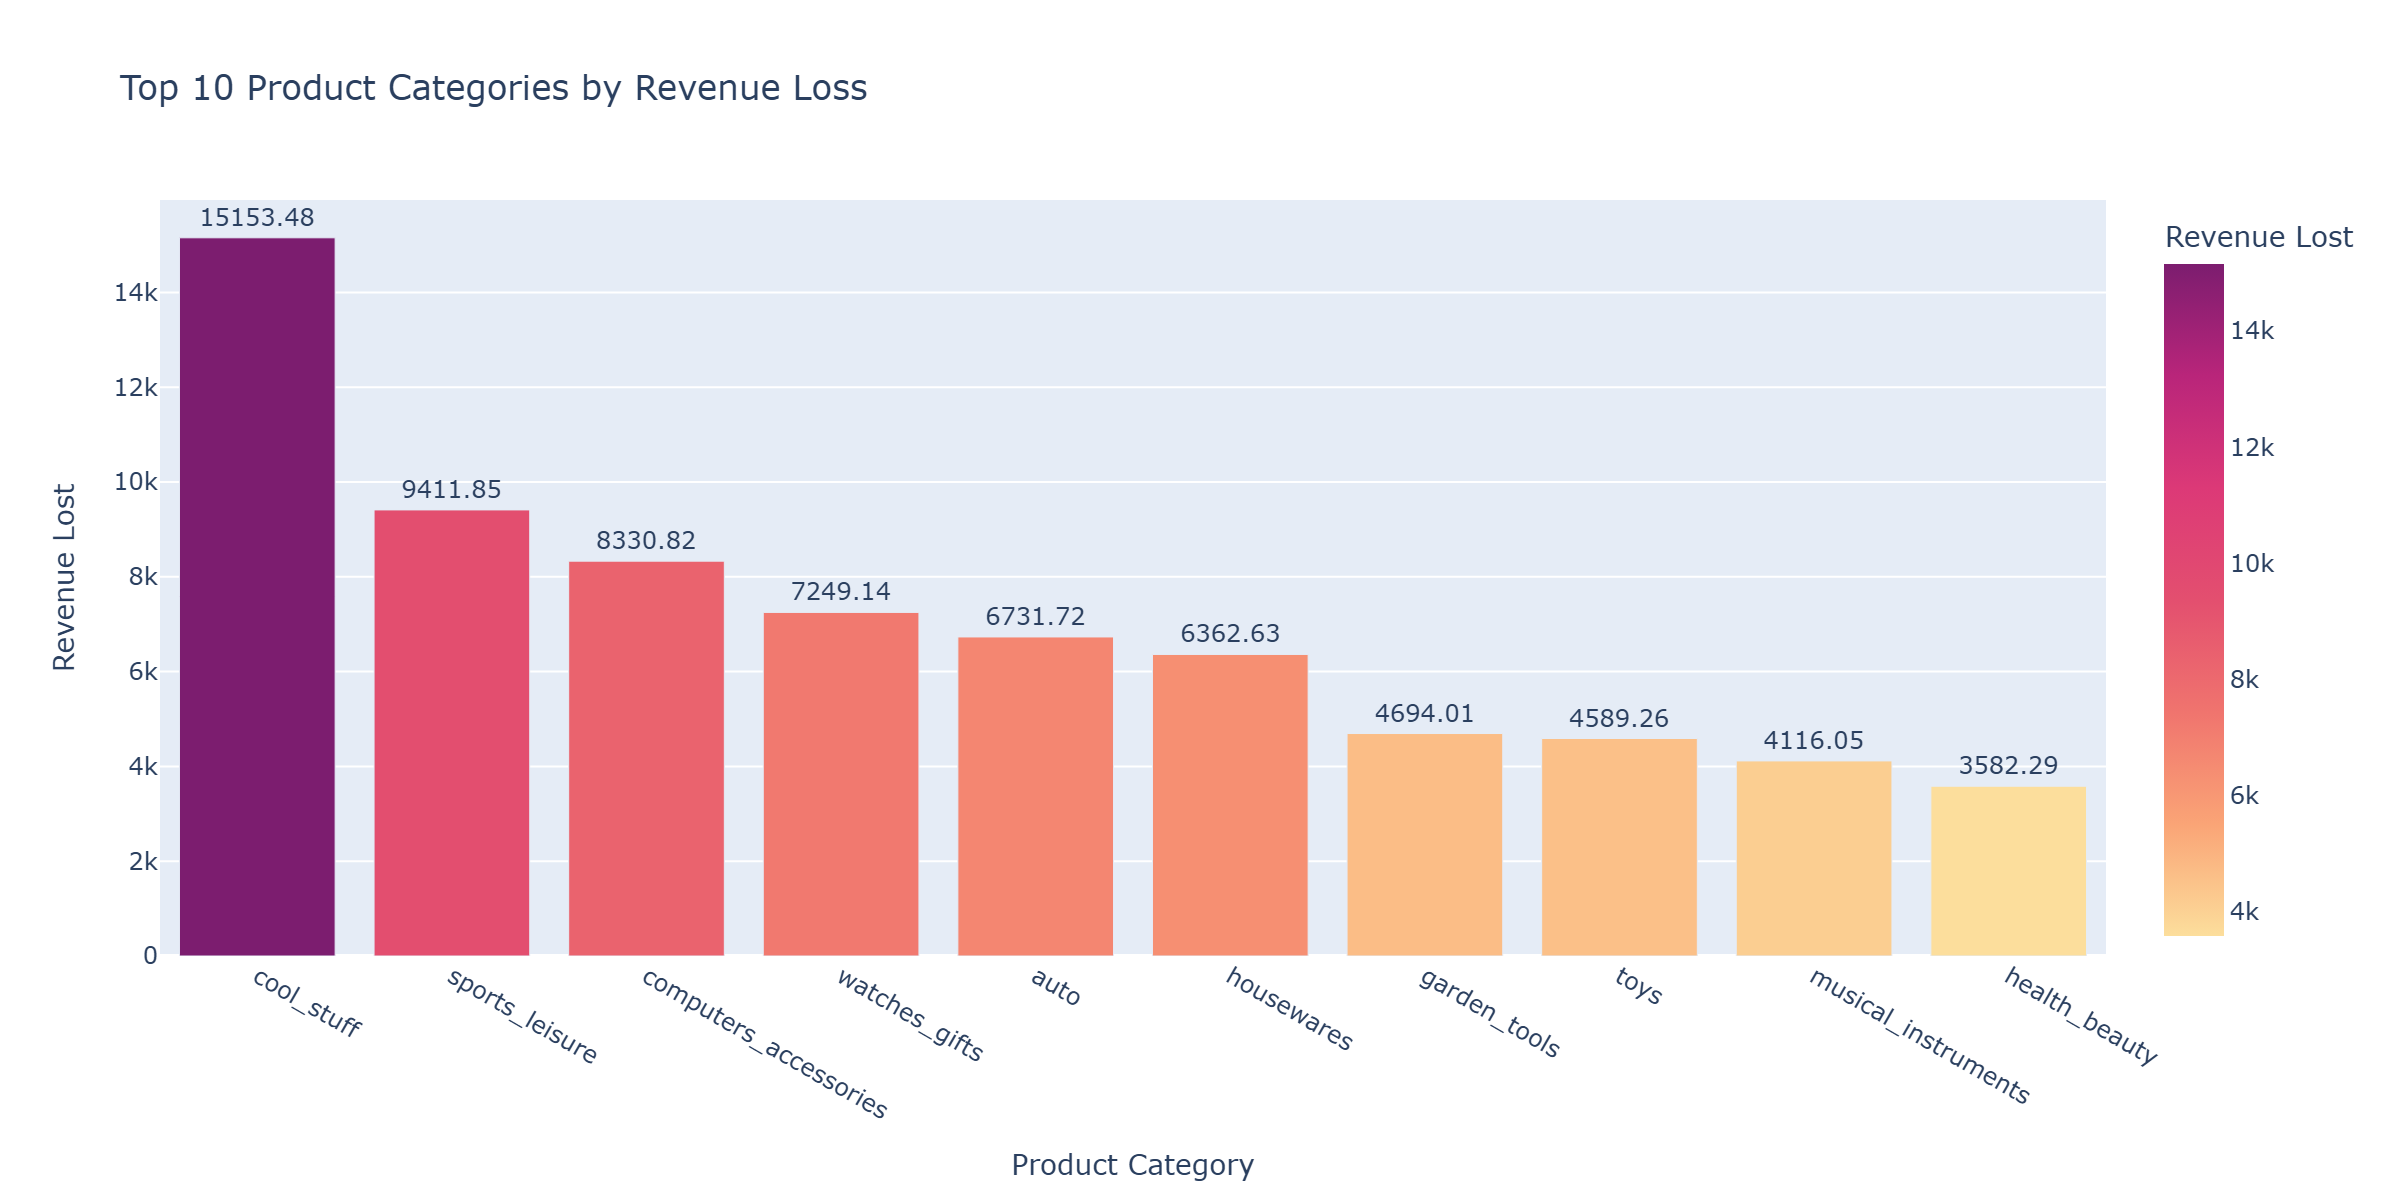

In [54]:
revenue_leakage_summary.category_level_revenue_leakage_summary(revenue_lost_per_prodct_cat,
                                                              prod_cat_w_max_amount, prod_cat_w_min_amount,
                                                            cancelled_orders, revenue_leakage_percentage, 
                                                               cancelled_orders_with_items_val,
                                                              cancelled_orders_without_items_val, fig)

## 3.4 Category Level Comparison (Volume vs Revenue)

### 3.4.1 Finding the total number of cancellations by product category:

In [58]:
# Get the total number of order cancelations by product category:
number_of_cancellations_by_product_category = revenue_leakage_metrics.get_cncl_by_prod_cat_volume(conn=conn, 
                                                                                                sql_base_path=SQL_BASE_PATH)

### 3.4.2 Joining the two DFs to compare cancellation counts and amounts per category:

In [59]:
revenue_lost_per_prodct_cat.head(2)

,product_category,total_amount,revenue_leak_percentage
0,cool_stuff,15153.48,14.311
1,sports_leisure,9411.85,8.889


In [60]:
number_of_cancellations_by_product_category.head(2)

,product_category,total_n_orders
0,sports_leisure,51
1,housewares,49


In [61]:
cncl_count_and_amount_by_prd_cat = pd.merge(revenue_lost_per_prodct_cat,
                                number_of_cancellations_by_product_category,
                                on='product_category',
                                how='inner')

In [62]:
cncl_count_and_amount_by_prd_cat.head(2)

,product_category,total_amount,revenue_leak_percentage,total_n_orders
0,cool_stuff,15153.48,14.311,16
1,sports_leisure,9411.85,8.889,51


### 3.4.3 Call the function to plot `Canceled Volume vs Revenue Loss`:

In [66]:
fig = revenue_leakage_plots.plot_cancelation_volume_vs_revenue_loss(cncl_count_and_amount_by_prd_cat)

In [67]:
reload_package()

Packages reloaded!!



## Category Level Comparison Analysis (Canceled Volume vs Revenue Loss) - Summary: 

----------------------------------------------------------------------------------------------------

To further understand the drivers of revenue leakage, a category-level comparison was conducted
between the **number of cancelled orders** and the **total revenue lost** per product category.

The scatter plot below visualizes this relationship:
- Each point represents a product category
- The x-axis shows the number of cancelled orders
- The y-axis shows the total revenue lost
- Color intensity (red scale) represents the magnitude of revenue loss


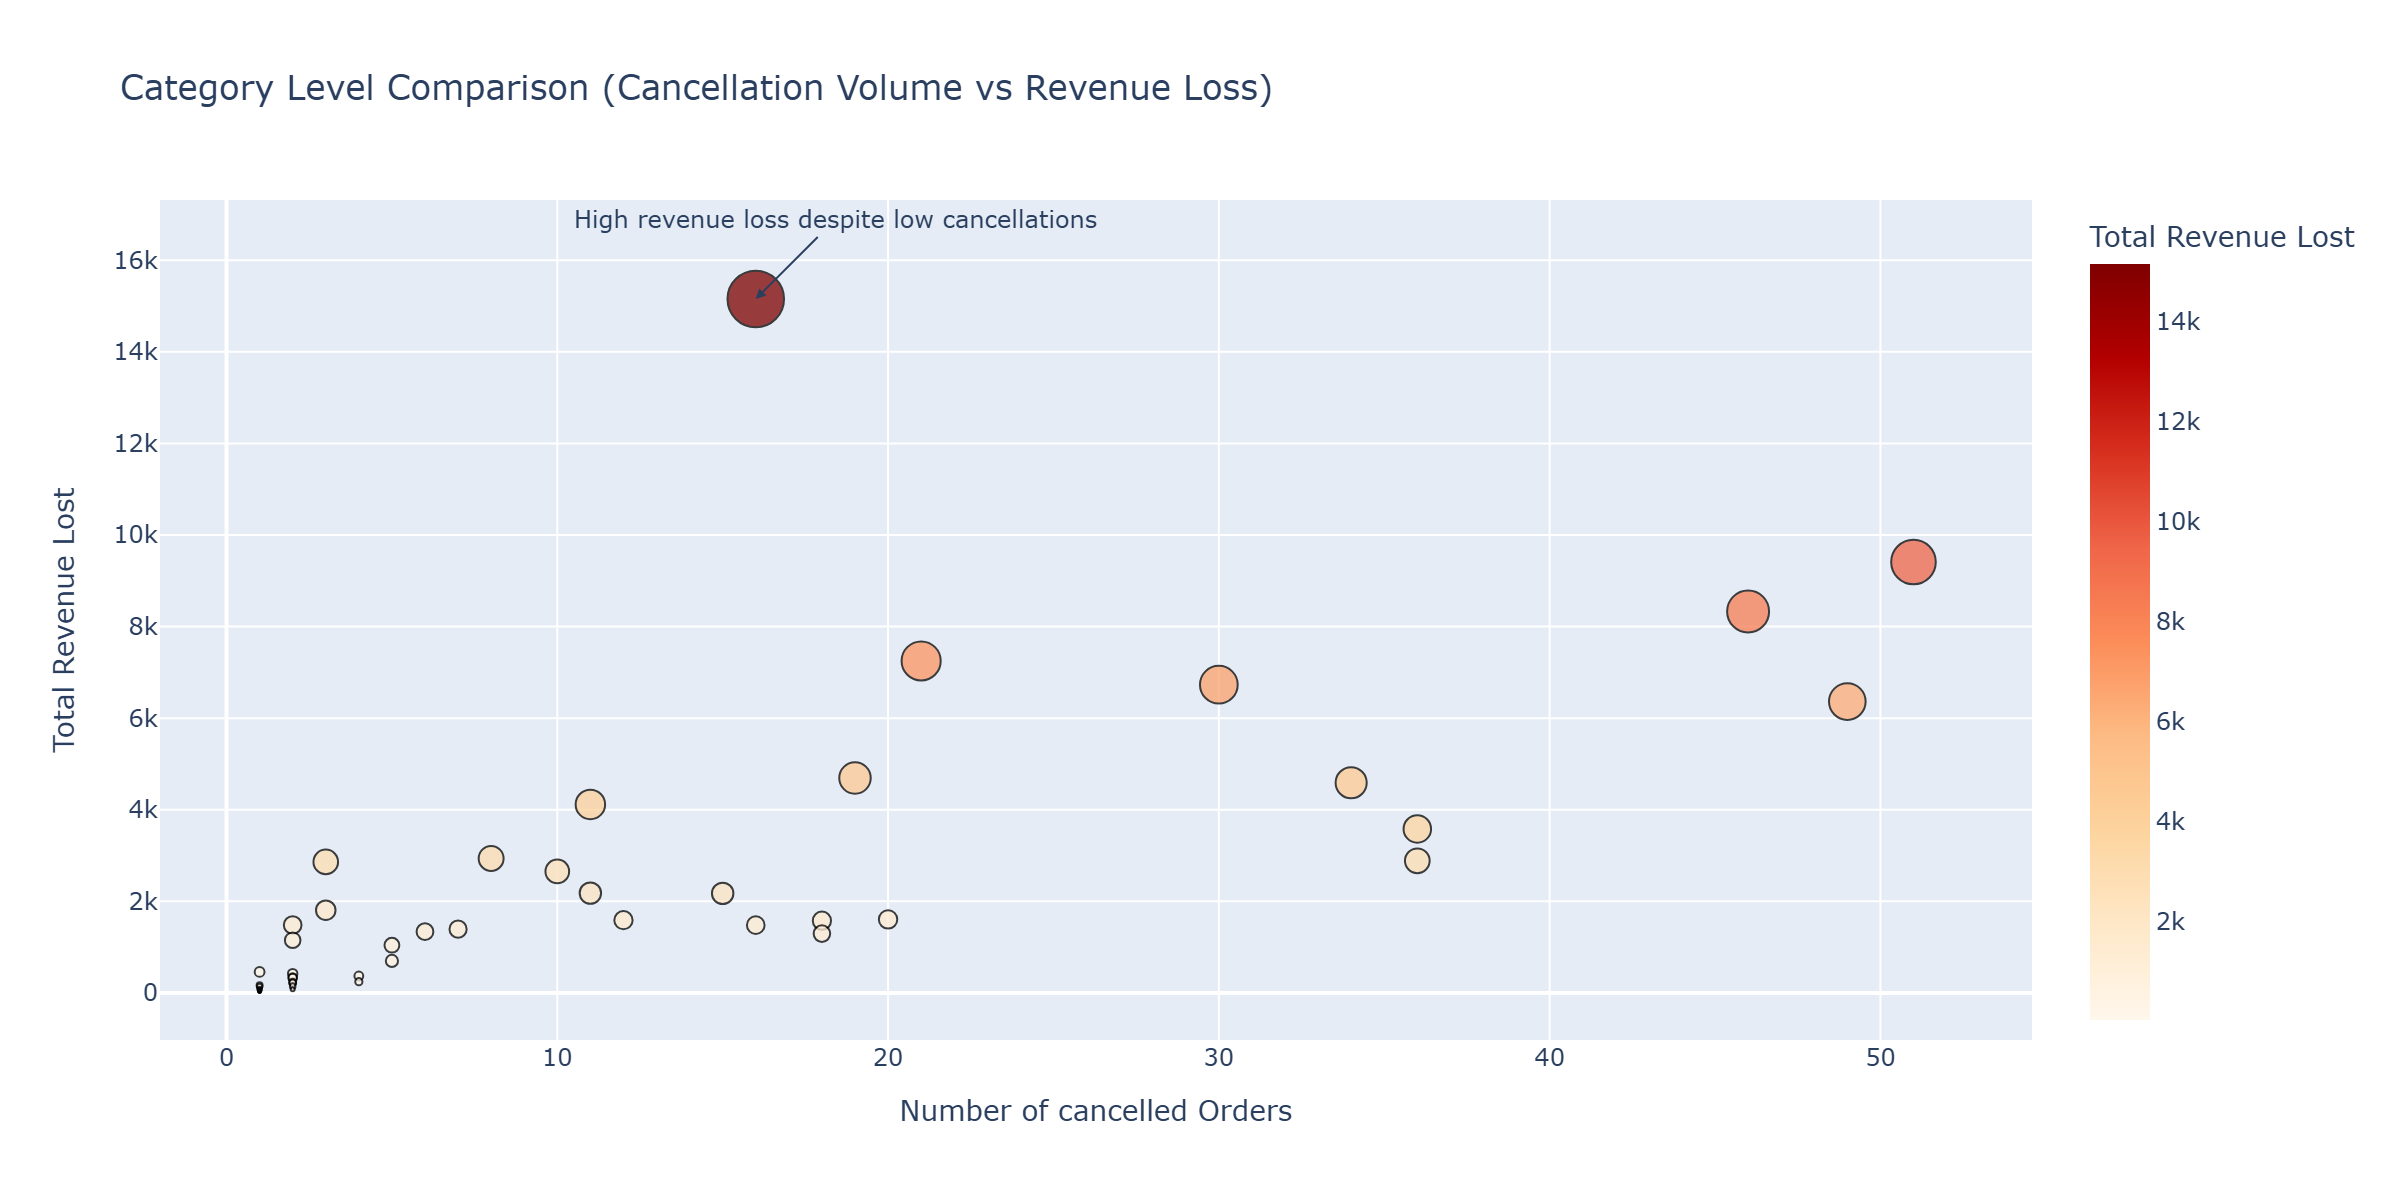


## Hypothesis Evaluation:

**Hypothesis 1:**  
*High-priced or logistics-heavy categories will show disproportionately high revenue loss, even if cancellation volume is low.*

**Supported:**  
- The visualization reveals at least one category with a relatively **low number of cancellations**
but **exceptionally high revenue loss**, indicating that high item value or logistics costs
can amplify financial impact even when cancellation volume is moderate.

---

**Hypothesis 2:**  
*Some categories may have high cancellation rates but low revenue impact, indicating operational inefficiencies rather than financial risk.*

**Supported:**  
- Several categories follow a near-linear relationship where higher cancellation volume
results in proportionally higher revenue loss. However, some categories exhibit
**high cancellation counts with comparatively lower revenue loss**, suggesting
process inefficiencies rather than major financial exposure.


There was just one outlier or a product category that is marked in the scatter plot above, where the number of cancellations
was low but the financial impact it had was high compared to all the products displayed below:


,product_category,total_amount,revenue_leak_percentage,total_n_orders
0,cool_stuff,15153.48,14.311,16



## Key Takeaways:

- Revenue leakage is **not solely driven by cancellation volume**
- Certain categories pose **higher financial risk per cancellation**
- Category-level analysis enables **prioritized intervention**:
  - High revenue loss categories → pricing, logistics, supplier review
  - High cancellation volume but low loss → operational and process improvements

This analysis highlights the importance of evaluating **both frequency and financial impact**
when addressing revenue leakage.


In [68]:
revenue_leakage_summary.category_lvl_vol_vs_rvn_summary(fig, cncl_count_and_amount_by_prd_cat)